# PriceSense: Used Car Price Predictor

**Machine Learning Internship, Week 1 project** | Author: Muhammad Azlan

Buyers and sellers on car marketplaces rarely know what a used car is really worth.
This notebook builds a model that predicts a fair market price (in PKR) from the car's brand, age, mileage,
engine size, city and a few other details, using the PakWheels used cars dataset.

**Notebook outline**

| Part | Content |
|---|---|
| 1 | Setup |
| 2 | Data loading and first look |
| 3 | Data cleaning |
| 4 | Feature engineering |
| 5 | Exploratory data analysis (9 insights) |
| 6 | Train/test split and Pipeline |
| 7 | Model comparison with cross-validation |
| 8 | Final model and test evaluation |
| 9 | Feature importance |
| 10 | Price range |
| 11 | Saving the model |
| 12 | Summary and limitations |

**How to run:** put `pakwheels_pakistan_automobile_dataset.csv` next to this notebook (in Colab: upload it and set `DATA_PATH` below), then use *Run all*.
The notebook creates `cleaned_cars.csv`, `model.joblib`, `model_metadata.json`, `feature_importance.csv` and `model_comparison.csv`.

---
## 1. Setup

In [1]:
import json
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import sklearn

from sklearn.model_selection import train_test_split, cross_validate, cross_val_predict
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
# Settings used across the notebook
DATA_PATH = 'pakwheels_pakistan_automobile_dataset.csv'   # in Colab: '/content/pakwheels_pakistan_automobile_dataset.csv'
REF_YEAR = 2024        # the listings were scraped in 2024, so car age is counted from this year
RANDOM_STATE = 42

---
## 2. Data loading and first look

In [3]:
df = pd.read_csv(DATA_PATH)
initial_rows = len(df)
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
df.head()

Rows: 48,189   Columns: 16


,title,price,city,model,mileage,fuel_type,transmission,registered,color,assembly,engine_capacity,post_date,price_category,mileage_category,post_day_of_week,vehicle_age
0,Honda N One Premium 2014,2650000,Lahore,2014,82000,Petrol,Automatic,Lahore,Blue,Imported,660,2024-05-04,Medium,Medium,Saturday,10
1,Nissan Note 2020,5400000,Lahore,2020,59000,Hybrid,Automatic,Un-Registered,Silver,Imported,1200,2024-05-04,High,Medium,Saturday,4
2,Suzuki Vitara GLX 1.6 2017,0,Karachi,2017,67000,Petrol,Automatic,Karachi,Grey,Imported,1600,2024-05-04,Low,Medium,Saturday,7
3,Toyota Yaris Cross 2021,7850000,Lahore,2021,41000,Hybrid,Automatic,Un-Registered,Beige,Imported,1500,2024-05-04,High,Low,Saturday,3
4,BMW X1 sDrive18i 2017,10700000,Islamabad,2017,37000,Petrol,Automatic,Islamabad,White,Imported,1500,2024-05-04,High,Low,Saturday,7


**Data dictionary**

| Column | Meaning | Type |
|---|---|---|
| `title` | Brand, variant and year of the car | text |
| `price` | Asking price in PKR (**target**) | number |
| `city` | City of the listing | category |
| `model` | Year of manufacture (despite the name) | number |
| `mileage` | Distance driven in km | number |
| `fuel_type` | Petrol, Hybrid, Diesel ... | category |
| `transmission` | Automatic or not available | category |
| `registered` | Registration city/province or un-registered | category |
| `color` | Car color | category |
| `assembly` | Imported or Local | category |
| `engine_capacity` | Engine size in cc | number |
| `post_date`, `post_day_of_week` | When the ad was posted | date / category |
| `price_category`, `mileage_category` | Low / Medium / High bins made from price and mileage | category |
| `vehicle_age` | Age of the car in years (as of the scrape) | number |

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48189 entries, 0 to 48188
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   title             48189 non-null  object
 1   price             48189 non-null  int64 
 2   city              48189 non-null  object
 3   model             48189 non-null  int64 
 4   mileage           48189 non-null  int64 
 5   fuel_type         48189 non-null  object
 6   transmission      48189 non-null  object
 7   registered        48189 non-null  object
 8   color             48189 non-null  object
 9   assembly          48189 non-null  object
 10  engine_capacity   48189 non-null  int64 
 11  post_date         48189 non-null  object
 12  price_category    48189 non-null  object
 13  mileage_category  48189 non-null  object
 14  post_day_of_week  48189 non-null  object
 15  vehicle_age       48189 non-null  int64 
dtypes: int64(5), object(11)
memory usage: 5.9+ MB


In [5]:
df.describe().round(1)

,price,model,mileage,engine_capacity,vehicle_age
count,48189.0,48189.0,48189.0,48189.0,48189.0
mean,4300610.7,2013.7,90444.9,1417.8,10.3
std,6285591.8,7.5,85300.6,715.8,7.5
min,0.0,1990.0,1.0,100.0,0.0
25%,1689999.0,2008.0,36000.0,1000.0,4.0
50%,3000000.0,2016.0,79192.0,1300.0,8.0
75%,4750000.0,2020.0,122456.0,1600.0,16.0
max,175000000.0,2024.0,1000000.0,15000.0,34.0


In [6]:
print('Missing values :', df.isna().sum().sum())
print('Duplicate rows :', df.duplicated().sum())
print()
print('Unique values per column:')
print(df.nunique())

Missing values : 0
Duplicate rows : 34

Unique values per column:
title               7349
price               2059
city                 312
model                 35
mileage             7396
fuel_type              4
transmission           3
registered            95
color                809
assembly               3
engine_capacity      146
post_date             31
price_category         3
mileage_category       3
post_day_of_week       7
vehicle_age           35
dtype: int64


In [7]:
print(df['city'].value_counts().head(10))
print()
print(df['transmission'].value_counts())

city
Lahore        10776
Karachi        9173
Islamabad      7777
Rawalpindi     3091
Peshawar       2186
Faisalabad     1677
Multan         1324
Gujranwala     1202
Sialkot         901
Sargodha        551
Name: count, dtype: int64

transmission
Automatic        29079
Not Available    19109
Manual               1
Name: count, dtype: int64


**Data quality issues found in this first look**

| Issue | Where |
|---|---|
| Duplicate rows | 34 rows |
| Price equal to 0 | minimum of `price` |
| Impossible engine sizes | `engine_capacity` from 100 cc to 15,000 cc |
| Impossible mileage | `mileage` as low as 1 km and as high as 1,000,000 km |
| Missing label hidden as text | `transmission` has "Not Available" |
| `price_category` is built from the target | would leak the answer, dropped later |

---
## 3. Data cleaning

Each step below removes or fixes one problem. A small log records how many rows each step removes,
so the full effect of the cleaning is visible in one table at the end.

In [8]:
cleaning_log = []

def log_step(name, rows_before, rows_after):
    cleaning_log.append({'Step': name, 'Rows removed': rows_before - rows_after, 'Rows left': rows_after})

### 3.1 Duplicates

In [9]:
before = len(df)
df = df.drop_duplicates()
log_step('Remove duplicate rows', before, len(df))
print('Rows left:', len(df))

Rows left: 48155


### 3.2 Zero prices

A price of 0 is a hidden missing value (the seller did not enter a price), so these rows cannot be used for training.

In [10]:
print('Rows with price = 0:', (df['price'] == 0).sum())

before = len(df)
df = df[df['price'] > 0]
log_step('Remove price = 0', before, len(df))

Rows with price = 0: 490


### 3.3 Rename `model` to `model_year`

The `model` column holds the year of manufacture, not the car model name. A clearer name avoids confusion later.

In [11]:
df = df.rename(columns={'model': 'model_year'})
df[['model_year']].describe().T

,count,mean,std,min,25%,50%,75%,max
model_year,47665.0,2013.629225,7.511156,1990.0,2008.0,2016.0,2020.0,2024.0


### 3.4 Engine capacity

Values below 600 cc or above 6000 cc are not normal passenger cars (the smallest real cars here, Japanese kei cars, are 660 cc).
I look at the rows first and then filter.

In [12]:
small = df['engine_capacity'] < 600
large = df['engine_capacity'] > 6000
print('Below 600 cc:', small.sum(), '| Above 6000 cc:', large.sum())

display(df.loc[small, ['title', 'model_year', 'engine_capacity', 'price']].head(8))
display(df.loc[large, ['title', 'model_year', 'engine_capacity', 'price']].head(8))

Below 600 cc: 49 | Above 6000 cc: 41


,title,model_year,engine_capacity,price
644,Prince K07 2019,2019,100,1650000
826,KIA Sportage 2008,2008,300,1400000
1393,Toyota Town Ace 1994,1994,220,1700000
8218,Ford Other 2020,2020,150,6000000
9262,Nissan Clipper 2012,2012,598,1325000
10512,Toyota Land Cruiser RKR 1987,1995,320,3250000
11601,Suzuki Bolan 1992,1992,100,400000
13717,KIA Classic 2001,2001,132,530000


,title,model_year,engine_capacity,price
399,GMC Sierra Denali 2020,2020,6600,59500000
606,Mercedes Benz C Class C63 AMG 2008,2008,6200,13500000
2525,Toyota Hiace 1994,1994,12000,2800000
3076,Mercedes Benz C Class C63 AMG 2010,2010,6208,12000000
3265,Mercedes Benz C Class C63 AMG 2010,2010,6200,15000000
3409,Ford F 150 Raptor SVT 2013,2013,6200,14200000
3512,Toyota Corolla 2009,2009,13000,2250000
4669,Mercedes Benz C Class C63 AMG 2011,2011,6200,12000000


In [13]:
before = len(df)
df = df[(df['engine_capacity'] >= 600) & (df['engine_capacity'] <= 6000)]
log_step('Engine capacity outside 600 to 6000 cc', before, len(df))

### 3.5 Very old cars with almost no mileage

A car older than 15 years with under 5,000 km is not realistic. These listings usually have a placeholder or a wrong mileage,
and they would teach the model a wrong link between age and mileage. I check how many rows are affected before removing them.

In [14]:
car_age_tmp = REF_YEAR - df['model_year']
old_low_km = (car_age_tmp > 15) & (df['mileage'] < 5000)

print('Suspicious rows:', old_low_km.sum(), f'({old_low_km.mean() * 100:.2f}% of the data)')
display(df.loc[old_low_km, ['title', 'model_year', 'mileage', 'price']].head(8))

Suspicious rows: 913 (1.92% of the data)


,title,model_year,mileage,price
45,Toyota Corolla G L Package 1.5 2005,2005,170,1380000
81,Honda Civic EXi Automatic 1999,1999,300,1200000
99,Hyundai Santro Club GV 2008,2008,151,1275000
100,Toyota Corolla 1998,1998,123,2150000
281,Honda City 2001,2001,100,1075000
527,Suzuki Cultus VXR 2007,2007,1,950000
561,Toyota Corolla SE Limited 1988,2006,786,795000
566,Jeep CJ 5 1960,2003,150,3100000


In [15]:
before = len(df)
df = df[~old_low_km]
log_step('Older than 15 years with under 5,000 km', before, len(df))

### 3.6 Outliers with the IQR method

- **Q1** is the value below which 25% of the data lies, **Q3** the value below which 75% lies.
- **IQR = Q3 - Q1** is the spread of the middle 50% of the cars.
- A value is an outlier if it is below `Q1 - 1.5 x IQR` or above `Q3 + 1.5 x IQR`.

This removes extreme prices and extreme mileages. A side effect is that very expensive (luxury) cars are removed too,
which I note as a limitation at the end.

In [16]:
def remove_iqr_outliers(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    low = q1 - 1.5 * iqr
    high = q3 + 1.5 * iqr

    kept = data[(data[col] >= low) & (data[col] <= high)]
    print(f'{col}: allowed range {low:,.0f} to {high:,.0f} | removed {len(data) - len(kept)} rows')
    return kept

In [17]:
before = len(df)
df = remove_iqr_outliers(df, 'price')
log_step('Price outliers (IQR)', before, len(df))

before = len(df)
df = remove_iqr_outliers(df, 'mileage')
log_step('Mileage outliers (IQR)', before, len(df))

price: allowed range -2,776,877 to 9,426,126 | removed 2856 rows
mileage: allowed range -82,500 to 249,500 | removed 1612 rows


### 3.7 Almost new mileage on cars that are not new

IQR does not catch values at the low end, so a second check is needed. Cars from 2024 or 2023 with a few km can be real
(unused stock). But a car that is 3 or more years old with under 100 km is not realistic.

In [18]:
low_km = df['mileage'] < 100
age = REF_YEAR - df['model_year']

print('Cars with under 100 km:', low_km.sum())
print('   age 0 to 2 years (can be real):', (low_km & (age <= 2)).sum())
print('   age 3 years or more (suspicious):', (low_km & (age >= 3)).sum())

Cars with under 100 km: 584
   age 0 to 2 years (can be real): 376
   age 3 years or more (suspicious): 208


In [19]:
before = len(df)
suspicious = (df['mileage'] < 100) & ((REF_YEAR - df['model_year']) >= 3)
df = df[~suspicious]
log_step('Under 100 km but 3+ years old', before, len(df))

### 3.8 Transmission

"Not Available" is replaced by "Unknown". Only "Automatic" is ever labelled in this dataset: there is no "Manual" value.
The "Unknown" cars are cheaper, older and mostly locally assembled, and their titles show many typically manual cars (Mehran, Cultus, Corolla GLi).
I do not call them "Manual" because that would be a guess, so they stay a separate category.

In [20]:
df['transmission'] = df['transmission'].replace('Not Available', 'Unknown')
df['transmission'].value_counts()

,count
transmission,
Automatic,24886
Unknown,17100


### 3.9 Title year that does not match `model_year`

The title ends with a year (for example "Suzuki Mehran VX 1988"). In some rows it disagrees with `model_year`
(that Mehran has `model_year` 2024 and a mileage of 1 km). In these rows `model_year` cannot be trusted,
which would also break the car age feature, so I remove them.

In [21]:
df['title_year'] = df['title'].str.extract(r'(\d{4})\s*$')[0].astype(float)
mismatch = df['title_year'] != df['model_year']

print('Rows where title year and model_year disagree:', mismatch.sum())
display(df.loc[mismatch, ['title', 'model_year', 'mileage', 'price']].sample(8, random_state=1))

Rows where title year and model_year disagree: 1207


,title,model_year,mileage,price
11641,MG HS Essence 2024,2022,8000,8050000
26244,Toyota Corolla XL 1988,2013,145000,1700000
34884,Suzuki Bolan 1987,2006,100000,520000
37589,Nissan Sunny 1985,2009,20200,380000
17632,Toyota Land Cruiser 1983,2004,40000,1850000
16799,Daihatsu Mira L 2024,2015,81000,3350000
16574,Toyota Corolla 1982,2015,19999,680000
11570,Daihatsu Charade 1985,2013,30000,330000


In [22]:
before = len(df)
df = df[~mismatch].drop(columns='title_year')
log_step('Title year does not match model_year', before, len(df))

### 3.10 Recent cars with a very low price

A 2021 Toyota Fortuner listed at 138,000 PKR is clearly a typing mistake. I remove cars from 2012 or later that are listed under 500,000 PKR.

In [23]:
too_cheap = (df['price'] < 500000) & (df['model_year'] >= 2012)
print('Rows:', too_cheap.sum())
display(df.loc[too_cheap, ['title', 'model_year', 'mileage', 'price']].head(8))

Rows: 9


,title,model_year,mileage,price
407,Toyota Yaris 2020,2020,67000,430000
1776,Suzuki Mehran VXR Euro II 2014,2014,60000,114999
18122,Daihatsu Cuore CX Automatic 2012,2012,20000,430000
38724,Suzuki Bolan 2015,2015,11253,122000
38726,Suzuki Bolan VX Euro II 2022,2022,45000,190000
39013,Suzuki Bolan VX 2012,2012,50000,225000
39650,Toyota Fortuner 2.7 G 2021,2021,8000,138000
45405,FAW Carrier Standard 2013,2013,96806,490000


In [24]:
before = len(df)
df = df[~too_cheap]
log_step('Cars from 2012+ priced under 500,000', before, len(df))

df = df.reset_index(drop=True)

### 3.11 Cleaning summary

In [25]:
summary = pd.DataFrame(cleaning_log)
display(summary)

print(f'Rows at the start: {initial_rows:,}')
print(f'Rows after cleaning: {len(df):,}  ({(1 - len(df) / initial_rows) * 100:.1f}% removed)')

,Step,Rows removed,Rows left
0,Remove duplicate rows,34,48155
1,Remove price = 0,490,47665
2,Engine capacity outside 600 to 6000 cc,90,47575
3,"Older than 15 years with under 5,000 km",913,46662
4,Price outliers (IQR),2856,43806
5,Mileage outliers (IQR),1612,42194
6,Under 100 km but 3+ years old,208,41986
7,Title year does not match model_year,1207,40779
8,"Cars from 2012+ priced under 500,000",9,40770


Rows at the start: 48,189
Rows after cleaning: 40,770  (15.4% removed)


---
## 4. Feature engineering

New columns that carry more useful information than the raw ones.

### 4.1 `make` (brand)

The brand is the first word of the title. Three brands have two words (Mercedes Benz, Land Rover, Range Rover), so I fix them by hand.

In [26]:
fix = {'Mercedes': 'Mercedes Benz', 'Range': 'Range Rover', 'Land': 'Land Rover'}
df['make'] = df['title'].str.split().str[0].replace(fix)

print('Number of brands:', df['make'].nunique())
df['make'].value_counts().head(10)

Number of brands: 54


,count
make,
Toyota,12463
Suzuki,11269
Honda,9424
Daihatsu,1902
KIA,1157
Nissan,1072
Hyundai,739
Mitsubishi,527
Changan,458


### 4.2 `car_age` and `mileage_per_year`

Age is more useful than the model year number. Mileage per year tells how hard the car was used.
Age is counted from 2024 because the listings were scraped in 2024.

In [27]:
df['car_age'] = REF_YEAR - df['model_year']

# a 2024 car has age 0, so at least 1 is used to avoid dividing by zero
df['mileage_per_year'] = df['mileage'] / df['car_age'].clip(lower=1)

df[['model_year', 'car_age', 'mileage', 'mileage_per_year']].describe().round(1)

,model_year,car_age,mileage,mileage_per_year
count,40770.0,40770.0,40770.0,40770.0
mean,2014.0,10.0,85637.7,10444.8
std,7.2,7.2,54252.7,6459.6
min,1990.0,0.0,1.0,0.5
25%,2010.0,4.0,42000.0,6250.0
50%,2016.0,8.0,81000.0,9500.0
75%,2020.0,14.0,120000.0,13500.0
max,2024.0,34.0,249200.0,177000.0


### 4.3 `brand_tier`

Economy, Mid or Luxury. This is my own grouping by market position, not an official one.
Brands that are not listed (Suzuki, Daihatsu, FAW, DFSK, Prince, United ...) are Economy.

In [28]:
luxury = ['Mercedes Benz', 'BMW', 'Audi', 'Lexus', 'Porsche', 'Land Rover',
          'Range Rover', 'Volvo', 'Cadillac', 'MINI']

mid = ['Toyota', 'Honda', 'Hyundai', 'KIA', 'Nissan', 'Mitsubishi', 'Mazda', 'Subaru',
       'Ford', 'Chevrolet', 'Changan', 'MG', 'Haval', 'Jeep', 'Peugeot', 'Proton',
       'Chery', 'Volkswagen', 'ORA', 'Renault', 'Fiat', 'SsangYong', 'Isuzu', 'BAIC']

def get_tier(make):
    if make in luxury:
        return 'Luxury'
    if make in mid:
        return 'Mid'
    return 'Economy'

df['brand_tier'] = df['make'].apply(get_tier)

# sanity check: the median price should go up from Economy to Luxury
df.groupby('brand_tier')['price'].agg(['count', 'median'])

,count,median
brand_tier,,
Economy,13634,1750000.0
Luxury,421,4750000.0
Mid,26715,3800000.0


### 4.4 Columns removed before modelling

| Column | Reason |
|---|---|
| `price_category` | built from the price, so it leaks the target |
| `mileage_category` | only a binned copy of mileage |
| `title` | thousands of different values, the useful part is already in `make` |
| `vehicle_age`, `model_year` | replaced by `car_age` |
| `post_date`, `post_day_of_week` | the posting day should not change the price |

In [29]:
drop_cols = ['title', 'price_category', 'mileage_category',
             'post_date', 'post_day_of_week', 'vehicle_age', 'model_year']
df = df.drop(columns=drop_cols)

print(df.shape)
print('Missing values:', df.isna().sum().sum())

df.to_csv('cleaned_cars.csv', index=False)
df.head()

(40770, 13)
Missing values: 0


,price,city,mileage,fuel_type,transmission,registered,color,assembly,engine_capacity,make,car_age,mileage_per_year,brand_tier
0,2650000,Lahore,82000,Petrol,Automatic,Lahore,Blue,Imported,660,Honda,10,8200.000000,Mid
1,5400000,Lahore,59000,Hybrid,Automatic,Un-Registered,Silver,Imported,1200,Nissan,4,14750.000000,Mid
2,7850000,Lahore,41000,Hybrid,Automatic,Un-Registered,Beige,Imported,1500,Toyota,3,13666.666667,Mid
3,3600000,Karachi,45000,Petrol,Automatic,Karachi,Unlisted,Local,1500,Honda,8,5625.000000,Mid
4,6475000,Lahore,59500,Petrol,Automatic,Lahore,Super White,Local,1800,Toyota,2,29750.000000,Mid


---
## 5. Exploratory data analysis

Nine charts, each followed by one insight. Prices in the charts are in lakh PKR (1 lakh = 100,000) where noted.

### 5.1 Price distribution

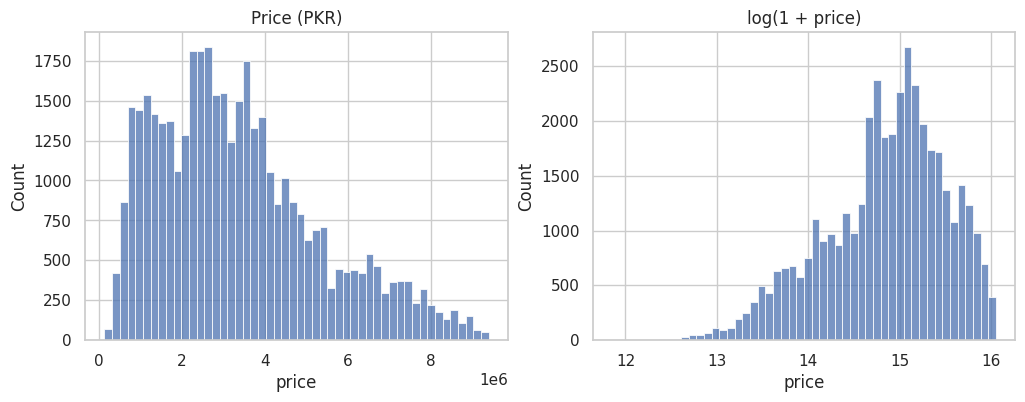

Skew of price     : 0.74
Skew of log(price): -0.59


In [30]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price'], bins=50, ax=ax[0])
ax[0].set_title('Price (PKR)')
sns.histplot(np.log1p(df['price']), bins=50, ax=ax[1])
ax[1].set_title('log(1 + price)')
plt.show()

print('Skew of price     :', round(df['price'].skew(), 2))
print('Skew of log(price):', round(np.log1p(df['price']).skew(), 2))

**Insight 1.** The middle half of the cars costs between 18.5 and 45.0 lakh (median 30.5 lakh), with a longer tail towards expensive cars.
The skew of the price is 0.74 and of the log price -0.59. The log makes the distribution more symmetric.
Section 7 checks whether training on the log of the price actually helps.

### 5.2 Price vs car age

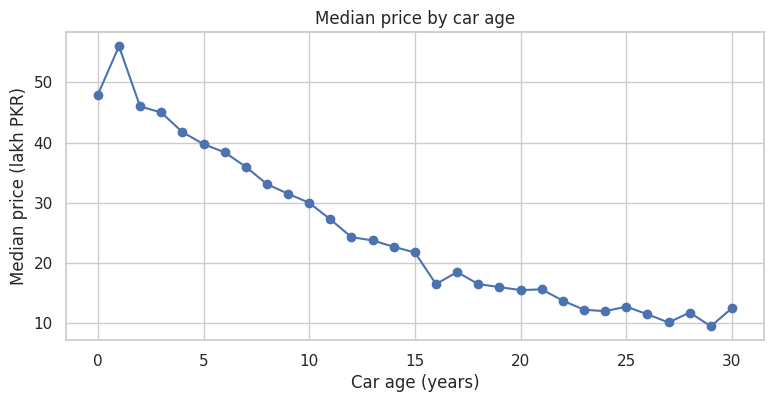

car_age
0     48.0
1     56.0
5     39.8
10    30.0
15    21.8
20    15.5
25    12.8
Name: price, dtype: float64


In [31]:
age_price = df.groupby('car_age')['price'].median() / 100000
age_price = age_price[age_price.index <= 30]

plt.figure(figsize=(9, 4))
age_price.plot(marker='o')
plt.xlabel('Car age (years)')
plt.ylabel('Median price (lakh PKR)')
plt.title('Median price by car age')
plt.show()

print(age_price.loc[[0, 1, 5, 10, 15, 20, 25]].round(1))

**Insight 2.** Price falls with age: the median is about 56.0 lakh at 1 year, 39.8 lakh at 5 years, 30.0 lakh at 10 years,
15.5 lakh at 20 years and 12.8 lakh at 25 years. Age 0 (2024 models) is a bit cheaper than age 1, probably because many 2024 listings are cheaper models.

### 5.3 Price vs mileage

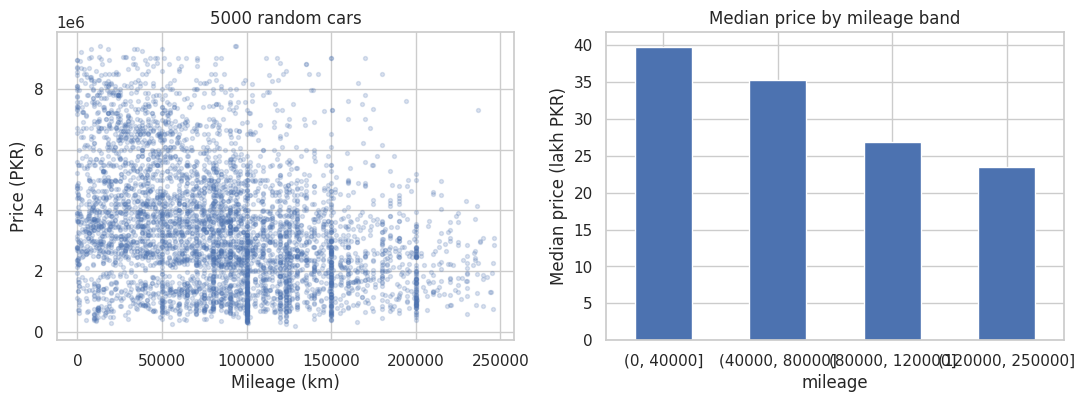

In [32]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

sample = df.sample(5000, random_state=1)
ax[0].scatter(sample['mileage'], sample['price'], alpha=0.2, s=8)
ax[0].set_xlabel('Mileage (km)')
ax[0].set_ylabel('Price (PKR)')
ax[0].set_title('5000 random cars')

mileage_bins = pd.cut(df['mileage'], [0, 40000, 80000, 120000, 250000])
(df.groupby(mileage_bins)['price'].median() / 100000).plot(kind='bar', ax=ax[1])
ax[1].set_ylabel('Median price (lakh PKR)')
ax[1].set_title('Median price by mileage band')
plt.xticks(rotation=0)
plt.show()

**Insight 3.** More km means a lower price: about 39.8 lakh below 40,000 km and about 23.5 lakh above 120,000 km.
The scatter is very spread out (correlation with price only -0.32), because mileage is linked with age and because brand and engine change the price a lot too.

### 5.4 Price by brand

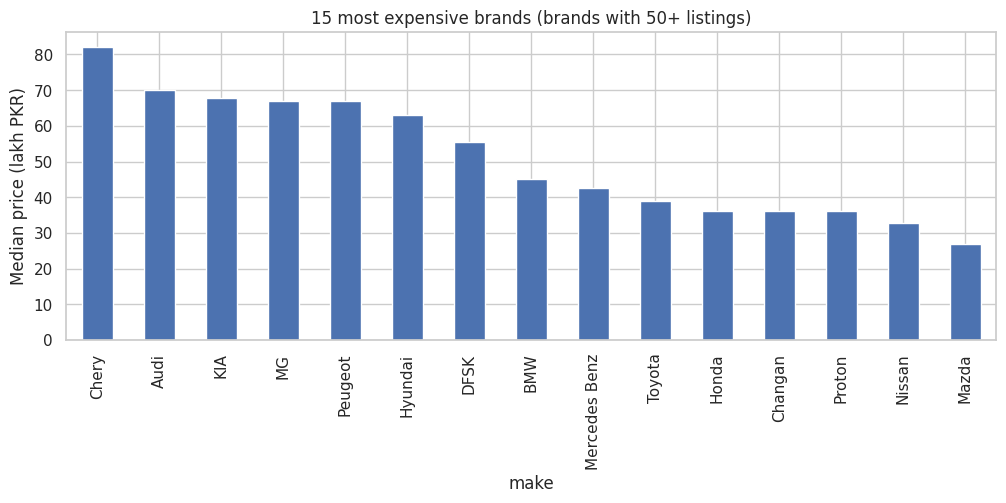

Cheapest brands:
make
Suzuki       16.0
Prince       14.0
FAW          13.5
Chevrolet     9.0
Name: price, dtype: float64


In [33]:
counts = df['make'].value_counts()
big_brands = counts[counts >= 50].index

make_price = df[df['make'].isin(big_brands)].groupby('make')['price'].median().sort_values(ascending=False) / 100000

plt.figure(figsize=(12, 4))
make_price.head(15).plot(kind='bar')
plt.ylabel('Median price (lakh PKR)')
plt.title('15 most expensive brands (brands with 50+ listings)')
plt.show()

print('Cheapest brands:')
print(make_price.tail(4).round(1))

**Insight 4.** The brands with the highest median price are Chery (82.2 lakh), Audi (70.0 lakh), KIA (67.8 lakh), MG (67.0 lakh), Peugeot (67.0 lakh). The cheapest are Chevrolet (9.0 lakh), FAW (13.5 lakh), Prince (14.0 lakh), Suzuki (16.0 lakh).
Part of this is age: for example KIA, MG and Hyundai listings are mostly recent cars, while many Suzukis are old.
Only brands with 50 or more listings are shown, so that one or two expensive cars do not decide a brand's rank.

### 5.5 Price by city

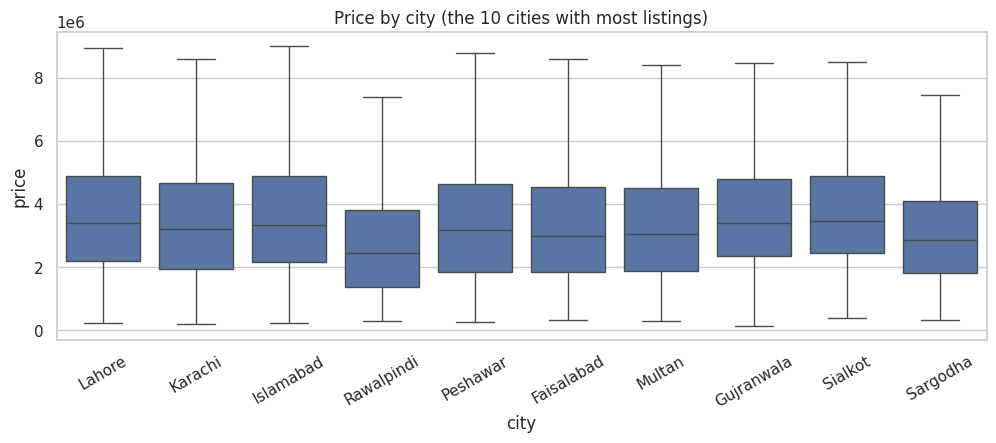

city
Rawalpindi    24.6
Sargodha      28.5
Faisalabad    30.0
Multan        30.5
Peshawar      31.9
Karachi       32.0
Islamabad     33.5
Gujranwala    33.8
Lahore        34.0
Sialkot       34.7
Name: price, dtype: float64


In [34]:
top_cities = df['city'].value_counts().head(10).index

plt.figure(figsize=(12, 4))
sns.boxplot(data=df[df['city'].isin(top_cities)], x='city', y='price',
            order=top_cities, showfliers=False)
plt.xticks(rotation=30)
plt.title('Price by city (the 10 cities with most listings)')
plt.show()

print((df[df['city'].isin(top_cities)].groupby('city')['price'].median() / 100000).sort_values().round(1))

**Insight 5.** City medians stay between 24.6 lakh (Rawalpindi) and 34.7 lakh (Sialkot).
This spread is smaller than the one between brands or ages, so I expect the city to be a weak feature.

### 5.6 Transmission, fuel type and assembly

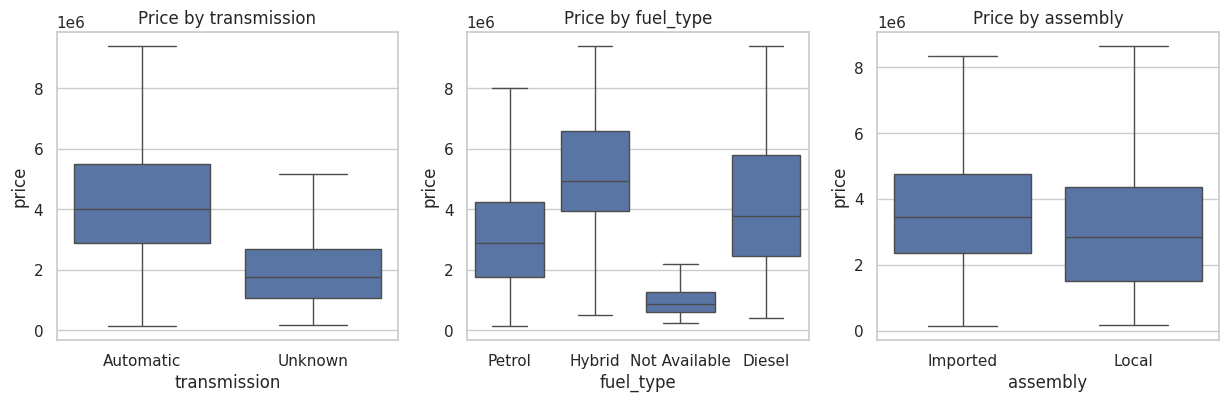

In [35]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ['transmission', 'fuel_type', 'assembly']):
    sns.boxplot(data=df, x=col, y='price', ax=a, showfliers=False)
    a.set_title('Price by ' + col)
plt.show()

**Insight 6.** Automatic cars have a median of 40.0 lakh against 17.5 lakh for "Unknown" transmission (mostly older local cars).
Among fuel types, Hybrid cars have a median of 49.5 lakh, Diesel 37.9 lakh and Petrol 28.7 lakh.
Imported cars are at 34.5 lakh and local cars at 28.4 lakh.

### 5.7 Engine capacity

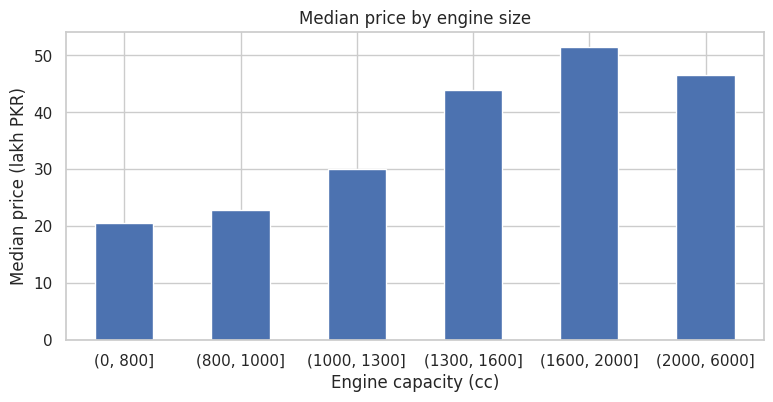

In [36]:
engine_bins = pd.cut(df['engine_capacity'], [0, 800, 1000, 1300, 1600, 2000, 6000])

(df.groupby(engine_bins)['price'].median() / 100000).plot(kind='bar', figsize=(9, 4))
plt.ylabel('Median price (lakh PKR)')
plt.xlabel('Engine capacity (cc)')
plt.title('Median price by engine size')
plt.xticks(rotation=0)
plt.show()

**Insight 7.** Median price goes from 20.5 lakh (up to 800 cc) to 51.5 lakh in the highest band (1600 to 2000 cc).
Above 2000 cc it is 46.5 lakh. So the relation is not a straight line, which is one reason to use tree models and not only linear regression.

### 5.8 Brand tier

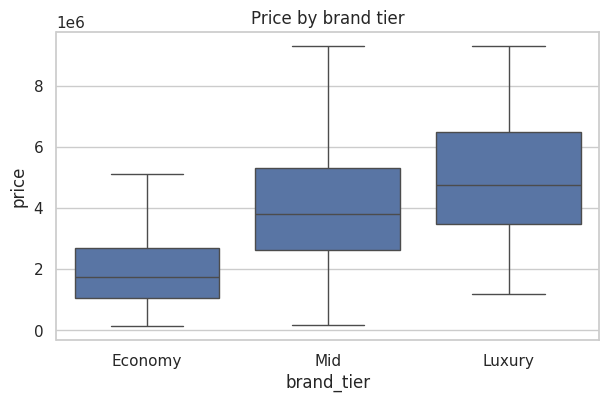

brand_tier
Mid        26715
Economy    13634
Luxury       421
Name: count, dtype: int64


In [37]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='brand_tier', y='price', order=['Economy', 'Mid', 'Luxury'], showfliers=False)
plt.title('Price by brand tier')
plt.show()

print(df['brand_tier'].value_counts())

**Insight 8.** Median price by tier: Economy 17.5 lakh, Mid 38.0 lakh, Luxury 47.5 lakh.
Only 421 cars (1.0% of the data) are Luxury, because the IQR step removed most of the expensive cars, so the model will be weak on luxury cars.

### 5.9 Correlation

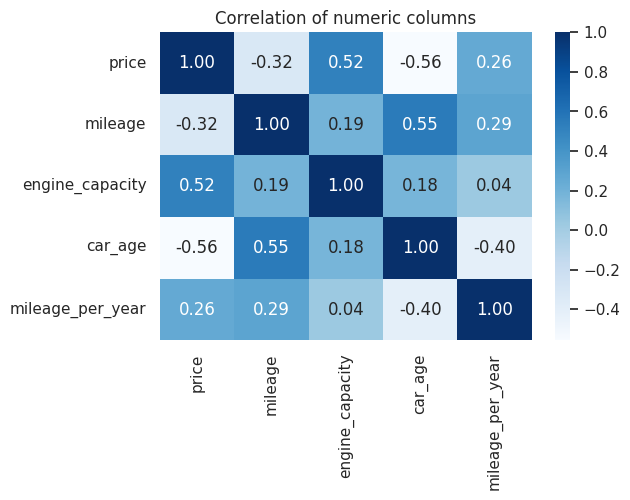

In [38]:
corr_cols = ['price', 'mileage', 'engine_capacity', 'car_age', 'mileage_per_year']

plt.figure(figsize=(6, 4))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('Correlation of numeric columns')
plt.show()

**Insight 9.** `car_age` (-0.56) and `engine_capacity` (+0.52) have the strongest link with price, then `mileage` (-0.32).
`mileage_per_year` has a correlation of +0.26. This is slightly positive, which surprised me. My guess is that newer, more expensive cars are driven more per year than very old ones, but I did not test this.

---
## 6. Train/test split and Pipeline

The data is split first and the test set stays untouched until the final evaluation.
Imputing, scaling and encoding live inside the Pipeline, so they are learned from the training data only. That prevents **data leakage**:
no information from the test set can influence the preprocessing.

In [39]:
X = df.drop(columns='price')
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Train: (32616, 12) | Test: (8154, 12)


In [40]:
num_cols = ['mileage', 'engine_capacity', 'car_age', 'mileage_per_year']
cat_cols = [c for c in X.columns if c not in num_cols]
print('Numeric    :', num_cols)
print('Categorical:', cat_cols)

Numeric    : ['mileage', 'engine_capacity', 'car_age', 'mileage_per_year']
Categorical: ['city', 'fuel_type', 'transmission', 'registered', 'color', 'assembly', 'make', 'brand_tier']


- **Numeric columns:** fill missing values with the median, then standardize (needed for Ridge).
- **Categorical columns:** fill missing values with the most frequent value, then one-hot encode.
  Categories with fewer than 30 cars are grouped together, and a category never seen in training does not crash the model.
- **Target:** the model learns `log(1 + price)` and predictions are converted back to PKR.

In [41]:
num_steps = Pipeline([
    ('fill', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])

cat_steps = Pipeline([
    ('fill', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist',
                             min_frequency=30, sparse_output=False)),
])

preprocess = ColumnTransformer([
    ('num', num_steps, num_cols),
    ('cat', cat_steps, cat_cols),
])

def make_pipeline(model, use_log=True):
    if use_log:
        model = TransformedTargetRegressor(regressor=model, func=np.log1p, inverse_func=np.expm1)
    return Pipeline([('prep', preprocess), ('model', model)])

---
## 7. Model comparison

Four models are compared with 5-fold cross-validation on the **training set only**:

- **Baseline:** always predicts the median price (the bar every model must beat)
- **Ridge:** a linear model
- **Random Forest** and **Gradient Boosting:** tree-based models that can learn non-linear patterns

Metrics: **MAE** (average error in PKR), **RMSE** (punishes big errors more) and **R2** (share of the price variation explained).

In [42]:
models = {
    'Baseline (median)': DummyRegressor(strategy='median'),
    'Ridge': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=18, min_samples_leaf=3,
                                           max_features=0.5, n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': HistGradientBoostingRegressor(max_iter=200, learning_rate=0.1,
                                                       random_state=RANDOM_STATE),
}

scoring = {'mae': 'neg_mean_absolute_error', 'rmse': 'neg_root_mean_squared_error', 'r2': 'r2'}

rows = []
for name, model in models.items():
    scores = cross_validate(make_pipeline(model), X_train, y_train, cv=5, scoring=scoring)
    rows.append({'Model': name,
                 'MAE': -scores['test_mae'].mean(),
                 'RMSE': -scores['test_rmse'].mean(),
                 'R2': scores['test_r2'].mean()})

results = pd.DataFrame(rows).set_index('Model')
results.round({'MAE': 0, 'RMSE': 0, 'R2': 3})

,MAE,RMSE,R2
Model,,,
Baseline (median),1564057.0,2003508.0,-0.029
Ridge,488244.0,778298.0,0.845
Random Forest,296450.0,492871.0,0.938
Gradient Boosting,315209.0,507480.0,0.934


**Observations.** Every real model is far better than the baseline (MAE 15.6 lakh). Ridge reaches 4.9 lakh,
Gradient Boosting 3.2 lakh and Random Forest 3.0 lakh. Random Forest is the best by cross-validation MAE. The big gap between Ridge and the tree models fits the EDA: the link between price and age or engine size is not a straight line.

### Does the log of the target help?

In [43]:
log_check = {}
for name in ['Random Forest', 'Gradient Boosting']:
    for use_log in [True, False]:
        s = cross_validate(make_pipeline(models[name], use_log=use_log),
                           X_train, y_train, cv=5, scoring=scoring)
        log_check[(name, use_log)] = (-s['test_mae'].mean(), s['test_r2'].mean())
        print(name, '| log target =', use_log, '| MAE:', round(-s['test_mae'].mean()), '| R2:', round(s['test_r2'].mean(), 3))

Random Forest | log target = True | MAE: 296450 | R2: 0.938
Random Forest | log target = False | MAE: 296519 | R2: 0.94
Gradient Boosting | log target = True | MAE: 315209 | R2: 0.934
Gradient Boosting | log target = False | MAE: 309386 | R2: 0.938


**Result.** Random Forest: MAE 296,536 (R2 0.938) with the log and 296,519 (R2 0.940) without. Gradient Boosting: 315,209 (R2 0.934) with the log and 309,386 (R2 0.938) without.
The log target makes almost no difference to the error. I keep the log in the pipeline because the project brief asks for it, it keeps predictions positive,
and it makes the model care about percentage errors instead of only large rupee errors.

---
## 8. Final model and test evaluation

The best model is chosen by its cross-validation MAE, not by looking at the test set. The test set is used once, here.

In [44]:
best_name = results['MAE'].idxmin()
print('Best model by cross-validation:', best_name)

final_model = make_pipeline(models[best_name])
final_model.fit(X_train, y_train)

Best model by cross-validation: Random Forest


Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('fill',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scale',
                                                                   StandardScaler())]),
                                                  ['mileage', 'engine_capacity',
                                                   'car_age',
                                                   'mileage_per_year']),
                                                 ('cat',
                                                  Pipeline(steps=[('fill',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='infrequent_if_exist',
                                                                                 min_frequency=30,
                                                                                 sparse_output=False))]),
                                                  ['city', 'fuel_type',
                                                   'transmission', 'registered',
                                                   'color', 'assembly', 'make',
                                                   'brand_tier'])])),
                ('model',
                 TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                            inverse_func=<ufunc 'expm1'>,
                                            regressor=RandomForestRegressor(max_depth=18,
                                                                            max_features=0.5,
                                                                            min_samples_leaf=3,
                                                                            n_jobs=-1,
                                                                            random_state=42)))])

In [45]:
pred = final_model.predict(X_test)

test_mae = mean_absolute_error(y_test, pred)
test_rmse = np.sqrt(mean_squared_error(y_test, pred))
test_r2 = r2_score(y_test, pred)
baseline_mae = (y_test - y_train.median()).abs().mean()
median_pct_error = np.median(np.abs(pred - y_test) / y_test) * 100

print(f'Test MAE : {test_mae:,.0f} PKR')
print(f'Test RMSE: {test_rmse:,.0f} PKR')
print(f'Test R2  : {test_r2:.3f}')
print()
print(f'Baseline MAE (always the median price): {baseline_mae:,.0f} PKR')
print(f'The model error is {test_mae / baseline_mae * 100:.0f}% of the baseline error')
print(f'Typical error per car: {median_pct_error:.1f}%')

Test MAE : 296,861 PKR
Test RMSE: 506,846 PKR
Test R2  : 0.935

Baseline MAE (always the median price): 1,566,949 PKR
The model error is 19% of the baseline error
Typical error per car: 6.3%


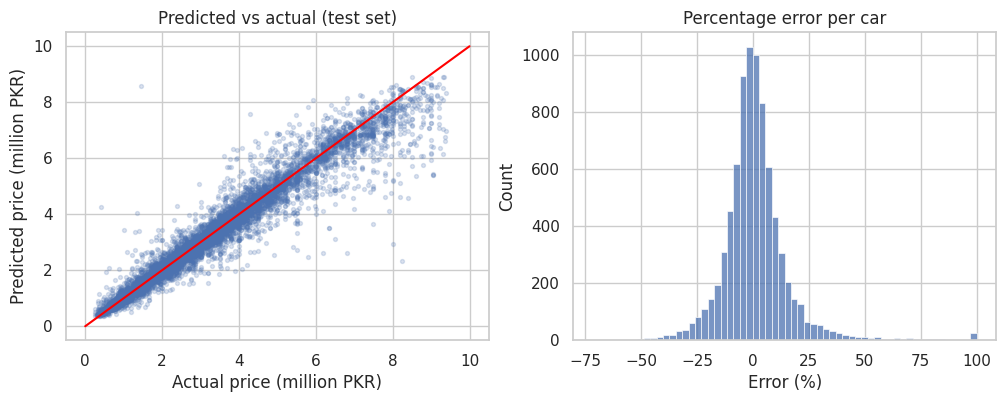

In [46]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].scatter(y_test / 1e6, pred / 1e6, alpha=0.2, s=8)
ax[0].plot([0, 10], [0, 10], color='red')
ax[0].set_xlabel('Actual price (million PKR)')
ax[0].set_ylabel('Predicted price (million PKR)')
ax[0].set_title('Predicted vs actual (test set)')

pct_error = (pred - y_test) / y_test * 100
sns.histplot(pct_error.clip(-100, 100), bins=60, ax=ax[1])
ax[1].set_xlabel('Error (%)')
ax[1].set_title('Percentage error per car')
plt.show()

In [47]:
# is the model equally good for cheap and expensive cars?
bands = pd.qcut(y_test, 4, labels=['cheapest 25%', '25-50%', '50-75%', 'most expensive 25%'])
band_table = pd.DataFrame({
    'MAE': (pred - y_test).abs().groupby(bands).mean().round(),
    'median error %': (np.abs(pred - y_test) / y_test * 100).groupby(bands).median().round(1),
})
band_table

,MAE,median error %
price,,
cheapest 25%,161505.0,9.6
25-50%,202483.0,5.8
50-75%,296175.0,5.4
most expensive 25%,534544.0,5.3


**Test result.** Test MAE is about 3.0 lakh PKR and R2 is 0.935. The cross-validation MAE was 3.0 lakh, so the two are close and the model is not overfitting.
The test error is 19% of the baseline error, and the typical car is predicted within about 6.3%.
Cheap cars have an error of 1.6 lakh (9.6%), the most expensive quarter 5.3 lakh (5.3%).

---
## 9. Feature importance

Permutation importance: one column is shuffled at a time, and the increase in error shows how much the model relies on it.

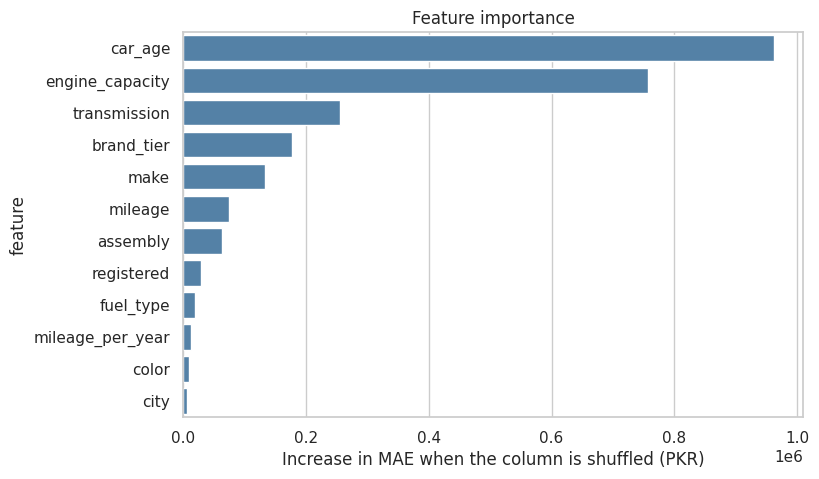

,feature,mae_increase
9,car_age,962180.0
7,engine_capacity,757262.0
3,transmission,255681.0
11,brand_tier,177817.0
8,make,133690.0
1,mileage,73777.0
6,assembly,62269.0
4,registered,28507.0
2,fuel_type,19417.0
10,mileage_per_year,11802.0


In [48]:
sample = X_test.sample(4000, random_state=RANDOM_STATE)
imp = permutation_importance(final_model, sample, y_test.loc[sample.index], n_repeats=5,
                             scoring='neg_mean_absolute_error', random_state=RANDOM_STATE)

importance = pd.DataFrame({'feature': X.columns, 'mae_increase': imp.importances_mean})
importance = importance.sort_values('mae_increase', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance, x='mae_increase', y='feature', color='steelblue')
plt.xlabel('Increase in MAE when the column is shuffled (PKR)')
plt.title('Feature importance')
plt.show()

importance.to_csv('feature_importance.csv', index=False)
importance.round(0)

**Insight.** `car_age` and `engine_capacity` matter most (shuffling them raises the error by about 9.6 and 7.6 lakh).
Next come `transmission`, `brand_tier`, `make`. The least important columns are `city` and `color` (both under 10,000 PKR).

---
## 10. Price range

The app should show a range, not only a single number. I use out-of-fold predictions on the training set (predictions for cars the model did not
train on) and look at the ratio `actual / predicted`. Its 10th and 90th percentile give a range that should contain about 80% of the cars.

In [49]:
oof_pred = cross_val_predict(final_model, X_train, y_train, cv=5)
ratio = y_train / oof_pred

ratio_low, ratio_high = ratio.quantile([0.10, 0.90])
print(f'Price range = prediction x {ratio_low:.3f} to prediction x {ratio_high:.3f}')

# check on the test set
inside = ((y_test >= pred * ratio_low) & (y_test <= pred * ratio_high)).mean()
print(f'Share of test cars inside the range: {inside * 100:.1f}%')

Price range = prediction x 0.863 to prediction x 1.156
Share of test cars inside the range: 80.6%


**Result.** The range is about 14% below to 16% above the prediction, and 80.8% of the test cars fall inside it (the target was 80%).

---
## 11. Saving the model

The whole Pipeline (preprocessing and model) is saved as one file. The library versions are printed because the same versions
must be used when the model is loaded in the app.

In [50]:
print('scikit-learn:', sklearn.__version__)
print('pandas      :', pd.__version__)
print('numpy       :', np.__version__)
print('joblib      :', joblib.__version__)

scikit-learn: 1.6.1
pandas      : 2.2.3
numpy       : 2.1.3
joblib      : 1.6.0


In [51]:
joblib.dump(final_model, 'model.joblib', compress=3)
print('Model file size (MB):', round(os.path.getsize('model.joblib') / 1e6, 1))

# reload test: the loaded model must give the same predictions
loaded = joblib.load('model.joblib')
same = np.allclose(loaded.predict(X_test.head(10)), final_model.predict(X_test.head(10)))
print('Reloaded model gives the same predictions:', same)

# unseen categories must not crash the model
odd = X_test.head(1).copy()
odd['city'] = 'Atlantis'
odd['make'] = 'NewBrand'
odd['color'] = 'Pink-Green'
print('Prediction with unseen categories:', round(loaded.predict(odd)[0]))

Model file size (MB): 19.9
Reloaded model gives the same predictions: True
Prediction with unseen categories: 4109271


In [52]:
# everything the Streamlit app needs
metadata = {
    'expected_columns': list(X.columns),
    'numeric_columns': num_cols,
    'categorical_options': {c: sorted(X_train[c].unique().tolist()) for c in cat_cols},
    'numeric_ranges': {c: [float(X_train[c].min()), float(X_train[c].max())] for c in num_cols},
    'reference_year': REF_YEAR,
    'make_fix': fix,
    'luxury_brands': luxury,
    'mid_brands': mid,
    'price_range_ratio': [float(ratio_low), float(ratio_high)],
    'model_name': best_name,
    'test_metrics': {'mae': float(test_mae), 'rmse': float(test_rmse), 'r2': float(test_r2)},
    'versions': {'sklearn': sklearn.__version__, 'pandas': pd.__version__, 'numpy': np.__version__},
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

results.round({'MAE': 0, 'RMSE': 0, 'R2': 3}).to_csv('model_comparison.csv')

print('Saved: model.joblib, model_metadata.json, feature_importance.csv, model_comparison.csv, cleaned_cars.csv')

Saved: model.joblib, model_metadata.json, feature_importance.csv, model_comparison.csv, cleaned_cars.csv


---
## 12. Summary and limitations

| Model | MAE (PKR) | R2 |
|---|---|---|
| Baseline (median price), cross-validation | about 1,564,000 | -0.029 |
| Ridge, cross-validation | about 488,000 | 0.845 |
| Gradient Boosting, cross-validation | about 315,000 | 0.934 |
| Random Forest, cross-validation | about 297,000 | 0.938 |
| **Random Forest, test set (used once)** | **about 297,000** | **0.935** |

The data went from 48,189 raw rows to 40,770 clean rows (15.4% removed).

**Limitations**

- Prices are 2024 asking prices from listings, not final sale prices, and they are not adjusted for inflation.
- Cars above about 9.4 million PKR were removed as outliers and only about 1.0% of the data is Luxury, so the model is not reliable for luxury cars.
- Only the brand is used, not the model name (Corolla, Civic ...), so two different models of the same brand and year look the same to the model.
  Extracting the model name from the title is the next improvement to try.
- About 40% of the listings have no transmission label ("Unknown"), most likely older manual cars.
- The data comes from one website, so cars that are not listed there are not covered.

**Next steps:** Streamlit app with price range and feature importance, deployment, and a README with these results.